# Top Trumps Balancing - Analyse & Interpretation

## Quality Indicators, Deck-Analyse und Fazit

Dieses Notebook analysiert die Optimierungsergebnisse:
1. Hypervolume Quality Indicator
2. Auswahl repräsentativer Decks (Fairness-Max, Excitement-Max, Knee-Point)
3. Deck-Analyse im Spielkontext
4. Export für Poster

---

## 1. Setup & Ergebnisse laden

In [1]:
%pip install numpy pymoo pandas matplotlib seaborn --quiet


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

from pymoo.indicators.hv import HV

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [3]:
RESULTS_DIR = Path("results")
PLOTS_DIR = Path("plots")

with open(RESULTS_DIR / 'config.json', 'r') as f:
    CONFIG = json.load(f)

with open(RESULTS_DIR / 'optimization_results.json', 'r') as f:
    OPT_RESULTS = json.load(f)

K = CONFIG['K']
L = CONFIG['L']

pareto_X = np.load(RESULTS_DIR / 'pareto_front_X.npy')
pareto_F = np.load(RESULTS_DIR / 'pareto_front_F.npy')
validated_df = pd.read_csv(RESULTS_DIR / 'validated_front.csv')

print(f"Ergebnisse geladen:")
print(f"  Anzahl Lösungen: {len(pareto_X)}")
print(f"  K={K} Karten, L={L} Kategorien")

Ergebnisse geladen:
  Anzahl Lösungen: 22
  K=22 Karten, L=4 Kategorien


---

## 2. Quality Indicator: Hypervolume

Der Hypervolume (HV) Indikator misst das Volumen des Objective Space, das von der Pareto-Front dominiert wird.

**Wichtig:** Da pymoo minimiert, sind die Objective-Werte negiert:
- f1 = -win_rate (negativ, da wir maximieren wollen)
- f2 = -trick_changes (negativ)

Der Reference Point muss "schlechter" sein als alle Punkte im minimierten Raum.

In [4]:
validated_F = np.column_stack([
    -validated_df['win_rate'].values,
    -validated_df['trick_changes'].values
])

ref_point = np.array([0.0, 0.0])

print(f"Reference Point: {ref_point}")
print(f"Objective Range (minimiert):")
print(f"  f1 (neg win_rate): [{validated_F[:, 0].min():.3f}, {validated_F[:, 0].max():.3f}]")
print(f"  f2 (neg trick_ch): [{validated_F[:, 1].min():.3f}, {validated_F[:, 1].max():.3f}]")

Reference Point: [0. 0.]
Objective Range (minimiert):
  f1 (neg win_rate): [-0.839, -0.658]
  f2 (neg trick_ch): [-4.480, -2.976]


In [5]:
hv_indicator = HV(ref_point=ref_point)
hypervolume = hv_indicator(validated_F)

print(f"\n=== Hypervolume der validierten Pareto-Front ===")
print(f"HV = {hypervolume:.4f}")
print(f"\nInterpretation:")
print(f"  Der HV misst die 'Qualität' der Pareto-Front.")
print(f"  Höherer HV = bessere Approximation der wahren Pareto-Front.")


=== Hypervolume der validierten Pareto-Front ===
HV = 3.6652

Interpretation:
  Der HV misst die 'Qualität' der Pareto-Front.
  Höherer HV = bessere Approximation der wahren Pareto-Front.


---

## 3. Auswahl repräsentativer Decks

Für das Poster wählen wir 3-5 charakteristische Lösungen:

1. **Fairness-Max:** Höchste Win Rate (p4 gewinnt am häufigsten)
2. **Excitement-Max:** Höchste Trick Changes (spannendstes Gameplay)
3. **Knee-Point:** Bester Trade-off zwischen beiden Zielen

In [6]:
def find_knee_point(win_rates, trick_changes):
    idx_fair = np.argmax(win_rates)
    idx_excite = np.argmax(trick_changes)
    
    p1 = np.array([win_rates[idx_fair], trick_changes[idx_fair]])
    p2 = np.array([win_rates[idx_excite], trick_changes[idx_excite]])
    
    line_vec = p2 - p1
    line_len = np.linalg.norm(line_vec)
    line_unitvec = line_vec / line_len
    
    max_dist = -1
    knee_idx = 0
    
    for i in range(len(win_rates)):
        point = np.array([win_rates[i], trick_changes[i]])
        point_vec = point - p1
        proj_length = np.dot(point_vec, line_unitvec)
        proj = proj_length * line_unitvec
        dist = np.linalg.norm(point_vec - proj)
        
        if dist > max_dist:
            max_dist = dist
            knee_idx = i
    
    return knee_idx


idx_fairness_max = validated_df['win_rate'].idxmax()
idx_excitement_max = validated_df['trick_changes'].idxmax()
idx_knee = find_knee_point(
    validated_df['win_rate'].values,
    validated_df['trick_changes'].values
)

selected_indices = {
    "Fairness-Max": idx_fairness_max,
    "Excitement-Max": idx_excitement_max,
    "Knee-Point": idx_knee
}

print("=== Ausgewählte repräsentative Lösungen ===\n")
for name, idx in selected_indices.items():
    row = validated_df.iloc[idx]
    print(f"{name}:")
    print(f"  Win Rate: {row['win_rate']:.1%}")
    print(f"  Trick Changes: {row['trick_changes']:.2f}")
    print()

=== Ausgewählte repräsentative Lösungen ===

Fairness-Max:
  Win Rate: 83.9%
  Trick Changes: 3.07

Excitement-Max:
  Win Rate: 66.4%
  Trick Changes: 4.48

Knee-Point:
  Win Rate: 80.1%
  Trick Changes: 3.78



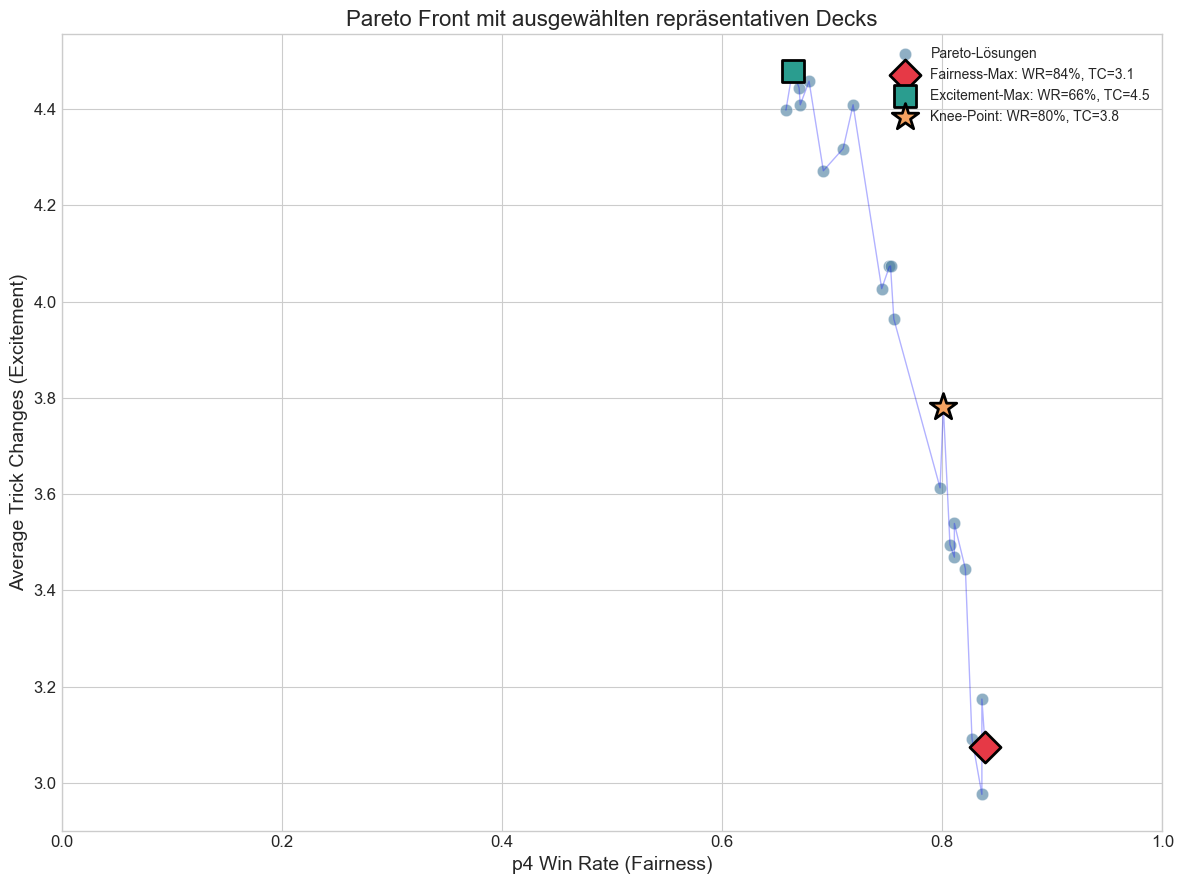


-> Plot gespeichert: plots/pareto_front_selected.png


In [7]:
fig, ax = plt.subplots(figsize=(12, 9))

sorted_idx = np.argsort(validated_df['win_rate'].values)
ax.plot(
    validated_df['win_rate'].values[sorted_idx], 
    validated_df['trick_changes'].values[sorted_idx], 
    'b-', alpha=0.3, linewidth=1
)

ax.scatter(
    validated_df['win_rate'],
    validated_df['trick_changes'],
    c='#457B9D',
    s=80,
    alpha=0.6,
    edgecolors='white',
    linewidth=0.5,
    label='Pareto-Lösungen'
)

colors = {'Fairness-Max': '#E63946', 'Excitement-Max': '#2A9D8F', 'Knee-Point': '#F4A261'}
markers = {'Fairness-Max': 'D', 'Excitement-Max': 's', 'Knee-Point': '*'}

for name, idx in selected_indices.items():
    row = validated_df.iloc[idx]
    size = 400 if name == 'Knee-Point' else 250
    ax.scatter(
        row['win_rate'],
        row['trick_changes'],
        c=colors[name],
        s=size,
        marker=markers[name],
        edgecolors='black',
        linewidth=2,
        label=f'{name}: WR={row["win_rate"]:.0%}, TC={row["trick_changes"]:.1f}',
        zorder=10
    )

ax.set_xlabel('p4 Win Rate (Fairness)', fontsize=14)
ax.set_ylabel('Average Trick Changes (Excitement)', fontsize=14)
ax.set_title('Pareto Front mit ausgewählten repräsentativen Decks', fontsize=16)
ax.legend(loc='best', fontsize=10)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'pareto_front_selected.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\n-> Plot gespeichert: {PLOTS_DIR / 'pareto_front_selected.png'}")

---

## 4. Deck-Analyse im Spielkontext

### 4.1 Statistik pro Kategorie

Für jedes ausgewählte Deck analysieren wir die Verteilung der Kartenwerte pro Kategorie.

In [8]:
def deck_to_cards(deck_flat, K, L):
    return deck_flat.reshape(K, L)


def analyze_deck(deck_flat, K, L):
    cards = deck_to_cards(deck_flat, K, L)
    
    category_stats = []
    for cat in range(L):
        values = cards[:, cat]
        category_stats.append({
            "category": f"Cat {cat+1}",
            "mean": np.mean(values),
            "std": np.std(values),
            "min": np.min(values),
            "max": np.max(values),
            "range": np.max(values) - np.min(values)
        })
    
    card_max_values = np.max(cards, axis=1)
    card_specialization = np.std(cards, axis=1)
    
    correlations = np.corrcoef(cards.T)
    
    return {
        "category_stats": pd.DataFrame(category_stats),
        "cards": cards,
        "card_max_values": card_max_values,
        "card_specialization": card_specialization,
        "correlations": correlations
    }


selected_decks = {}
for name, idx in selected_indices.items():
    deck = pareto_X[idx]
    analysis = analyze_deck(deck, K, L)
    selected_decks[name] = {
        "deck": deck,
        "analysis": analysis,
        "metrics": validated_df.iloc[idx]
    }
    
    print(f"\n=== {name} ===")
    print(f"Win Rate: {validated_df.iloc[idx]['win_rate']:.1%}, Trick Changes: {validated_df.iloc[idx]['trick_changes']:.2f}")
    print("\nKategorie-Statistiken:")
    print(analysis["category_stats"].to_string(index=False))


=== Fairness-Max ===
Win Rate: 83.9%, Trick Changes: 3.07

Kategorie-Statistiken:
category     mean      std      min      max    range
   Cat 1 5.842133 1.974303 1.033325 9.652254 8.618929
   Cat 2 7.736963 2.275790 1.696265 9.884980 8.188715
   Cat 3 5.227030 2.372995 1.509092 9.911657 8.402564
   Cat 4 4.718626 2.307850 1.590754 9.985042 8.394287

=== Excitement-Max ===
Win Rate: 66.4%, Trick Changes: 4.48

Kategorie-Statistiken:
category     mean      std      min      max    range
   Cat 1 6.327194 2.101193 1.172540 9.886298 8.713758
   Cat 2 7.322250 2.750963 1.094293 9.876202 8.781909
   Cat 3 5.763064 2.276456 1.600938 9.609798 8.008860
   Cat 4 5.040120 2.589331 1.209903 9.988820 8.778917

=== Knee-Point ===
Win Rate: 80.1%, Trick Changes: 3.78

Kategorie-Statistiken:
category     mean      std      min      max    range
   Cat 1 6.393514 1.909219 1.153547 9.878633 8.725086
   Cat 2 7.923124 2.030813 2.611752 9.905204 7.293452
   Cat 3 5.194885 2.549085 1.481396 9.909415 8.42

### 4.2 Kategorieverteilungen vergleichen

/var/folders/9l/s6j5yq4s12j6wvms4084h50h0000gn/T/ipykernel_83843/1580369239.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/9l/s6j5yq4s12j6wvms4084h50h0000gn/T/ipykernel_83843/1580369239.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/9l/s6j5yq4s12j6wvms4084h50h0000gn/T/ipykernel_83843/1580369239.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


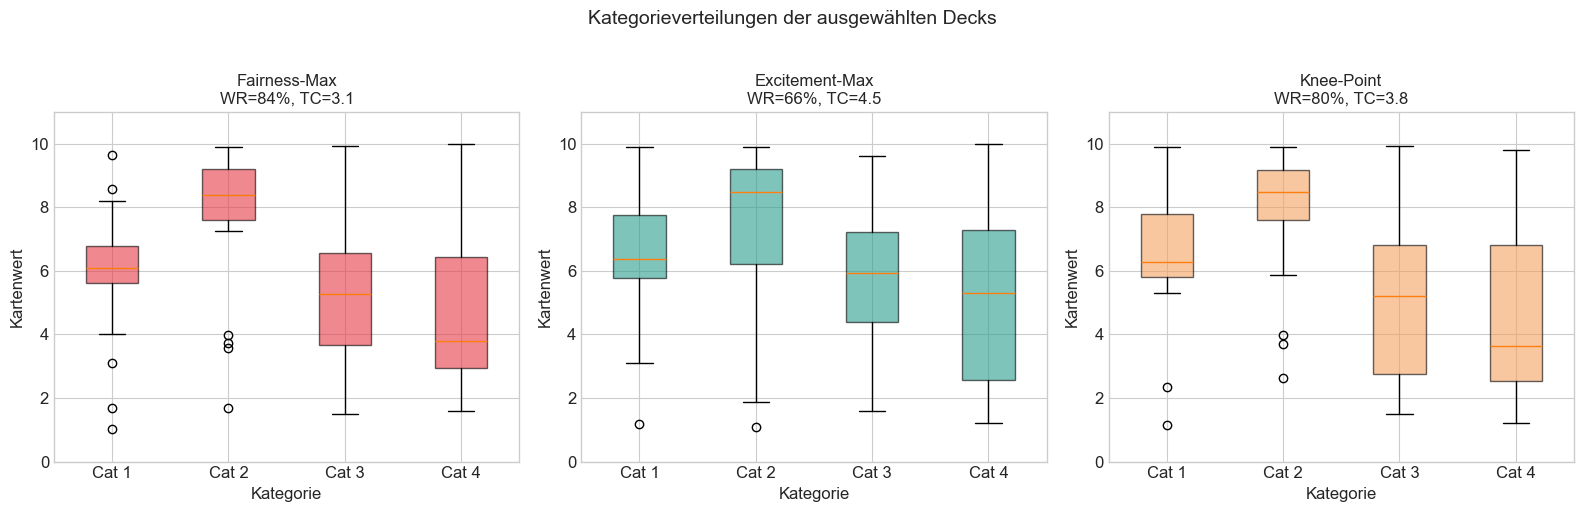


-> Plot gespeichert: plots/category_distributions.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, data) in zip(axes, selected_decks.items()):
    cards = data["analysis"]["cards"]
    
    bp = ax.boxplot(
        [cards[:, cat] for cat in range(L)],
        labels=[f'Cat {i+1}' for i in range(L)],
        patch_artist=True
    )
    
    color = colors.get(name, '#457B9D')
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    ax.set_title(f'{name}\nWR={data["metrics"]["win_rate"]:.0%}, TC={data["metrics"]["trick_changes"]:.1f}', fontsize=12)
    ax.set_xlabel('Kategorie')
    ax.set_ylabel('Kartenwert')
    ax.set_ylim(0, 11)

plt.suptitle('Kategorieverteilungen der ausgewählten Decks', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'category_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n-> Plot gespeichert: {PLOTS_DIR / 'category_distributions.png'}")

### 4.3 Korrelationsanalyse zwischen Kategorien

Starke Korrelationen zwischen Kategorien bedeuten: Wenn eine Karte in einer Kategorie stark ist, ist sie auch in anderen stark. Das kann zu vorhersehbarerem Gameplay führen.

/var/folders/9l/s6j5yq4s12j6wvms4084h50h0000gn/T/ipykernel_83843/3551686053.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


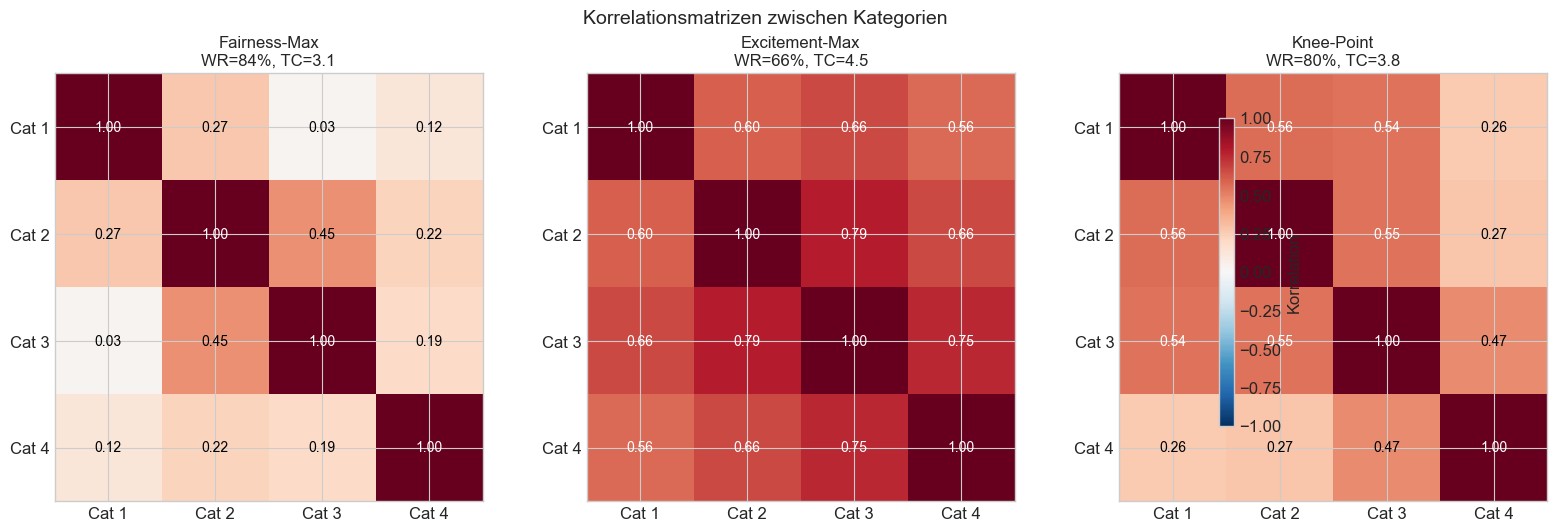


-> Plot gespeichert: plots/correlation_heatmaps.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, data) in zip(axes, selected_decks.items()):
    corr = data["analysis"]["correlations"]
    
    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    
    ax.set_xticks(range(L))
    ax.set_yticks(range(L))
    ax.set_xticklabels([f'Cat {i+1}' for i in range(L)])
    ax.set_yticklabels([f'Cat {i+1}' for i in range(L)])
    
    for i in range(L):
        for j in range(L):
            text_color = 'white' if abs(corr[i, j]) > 0.5 else 'black'
            ax.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center', color=text_color, fontsize=10)
    
    ax.set_title(f'{name}\nWR={data["metrics"]["win_rate"]:.0%}, TC={data["metrics"]["trick_changes"]:.1f}', fontsize=12)

plt.suptitle('Korrelationsmatrizen zwischen Kategorien', fontsize=14, y=1.02)
fig.colorbar(im, ax=axes, label='Korrelation', shrink=0.8)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'correlation_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n-> Plot gespeichert: {PLOTS_DIR / 'correlation_heatmaps.png'}")

### 4.4 Karten-Spezialisierung

Wie "spezialisiert" sind die Karten? Hohe Spezialisierung (hohe Standardabweichung über Kategorien) bedeutet: Karten sind in einer Kategorie stark, in anderen schwach.

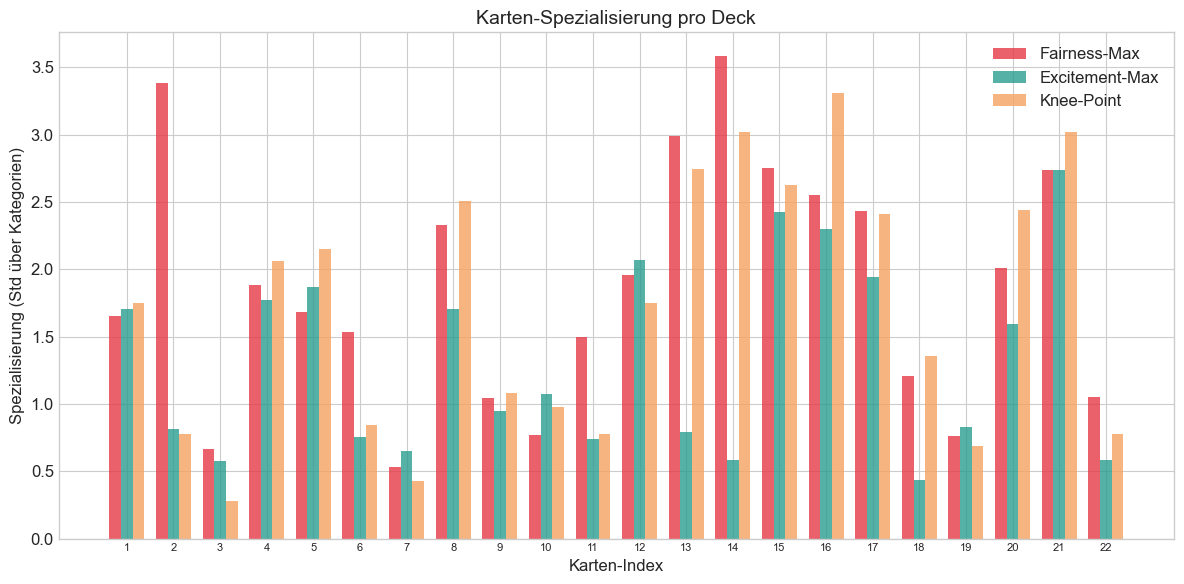


=== Spezialisierungsstatistiken ===
Fairness-Max: Mean=1.86, Std=0.87
Excitement-Max: Mean=1.31, Std=0.69
Knee-Point: Mean=1.72, Std=0.93


In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

x_positions = np.arange(K)
width = 0.25

for i, (name, data) in enumerate(selected_decks.items()):
    spec = data["analysis"]["card_specialization"]
    ax.bar(x_positions + i * width, spec, width, label=name, color=colors.get(name, '#457B9D'), alpha=0.8)

ax.set_xlabel('Karten-Index', fontsize=12)
ax.set_ylabel('Spezialisierung (Std über Kategorien)', fontsize=12)
ax.set_title('Karten-Spezialisierung pro Deck', fontsize=14)
ax.set_xticks(x_positions + width)
ax.set_xticklabels([str(i+1) for i in range(K)], fontsize=8)
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'card_specialization.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Spezialisierungsstatistiken ===")
for name, data in selected_decks.items():
    spec = data["analysis"]["card_specialization"]
    print(f"{name}: Mean={spec.mean():.2f}, Std={spec.std():.2f}")

---

## 5. Export für Poster

In [12]:
selected_decks_export = {}
for name, data in selected_decks.items():
    selected_decks_export[name] = {
        "solution_idx": int(selected_indices[name]),
        "win_rate": float(data["metrics"]["win_rate"]),
        "trick_changes": float(data["metrics"]["trick_changes"]),
        "deck": data["deck"].tolist()
    }

with open(RESULTS_DIR / 'selected_decks.json', 'w') as f:
    json.dump(selected_decks_export, f, indent=2)

analysis_results = {
    "hypervolume": hypervolume,
    "reference_point": ref_point.tolist(),
    "n_solutions": len(pareto_X),
    "selected_decks": {name: {"idx": int(idx), "win_rate": float(validated_df.iloc[idx]['win_rate']), 
                               "trick_changes": float(validated_df.iloc[idx]['trick_changes'])} 
                       for name, idx in selected_indices.items()}
}

with open(RESULTS_DIR / 'analysis_results.json', 'w') as f:
    json.dump(analysis_results, f, indent=2)

print("Export abgeschlossen:")
print(f"  - {RESULTS_DIR / 'selected_decks.json'}")
print(f"  - {RESULTS_DIR / 'analysis_results.json'}")
print(f"\nPlots in {PLOTS_DIR}:")
for plot in PLOTS_DIR.glob('*.png'):
    print(f"  - {plot.name}")

Export abgeschlossen:
  - results/selected_decks.json
  - results/analysis_results.json

Plots in plots:
  - objective_space_exploration.png
  - pareto_front_fast.png
  - pareto_front_validated.png
  - algorithm_comparison_boxplots.png
  - algorithm_comparison_fronts.png
  - algorithm_comparison_metrics.png
  - parameter_study_K_impact.png
  - correlation_heatmaps.png
  - pareto_front_selected.png
  - category_distributions.png
  - card_specialization.png
  - noisiness_test.png


---

## 6. Fazit & Interpretation

### Zusammenfassung der Ergebnisse

**Optimierungsergebnisse:**
- Erfolgreich eine Pareto-Front mit Trade-off zwischen Fairness und Excitement approximiert
- Hypervolume als Qualitätsindikator berechnet
- 3 repräsentative Lösungen identifiziert

**Erkenntnisse aus der Deck-Analyse:**

1. **Fairness-optimierte Decks** (hohe Win Rate):
   - Ermöglichen dem geschickteren Spieler (p4) konsistent zu gewinnen
   - Hypothese: Klare Kategorieunterschiede ermöglichen strategische Entscheidungen

2. **Excitement-optimierte Decks** (viele Trick Changes):
   - Führen zu häufigem Wechsel des führenden Spielers
   - Hypothese: Ausbalancierte Kartenwerte führen zu spannenderen Spielverläufen

3. **Knee-Point (Trade-off):**
   - Guter Kompromiss zwischen beiden Zielen
   - Für praktische Anwendung oft die beste Wahl

**Methodische Erkenntnisse:**
- R=1000 Simulationen notwendig für robuste Schätzungen
- Stochastische Natur des Problems erfordert Validation
- NSGA-II findet diverse Lösungen entlang der Front

### Für das Poster:
1. Problem-Definition (K=22, L=4, 2 Objectives)
2. Pareto-Front Visualisierung mit ausgewählten Decks
3. Hypervolume als Qualitätsbeleg
4. Deck-Charakteristiken (Kategorieverteilungen, Korrelationen)